# 機械学習で作付／休耕を自動判別してみる（scikit-learn 編）

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/astrocamp-2026-siaPpts/astrocamp-2026-sia/blob/main/tutorials/03_machine_learning.ipynb)

> **Private リポジトリの注意:** このリポジトリは Private 設定のため、上のバッジから直接開けない場合があります。
> その場合は [Google Colab](https://colab.research.google.com/) で「ファイル → ノートブックを開く → GitHub → プライベート リポジトリを含める」から開いてください。

チュートリアル 02 では、農地の **NDVI（光学）と VH（SAR）の時系列** を手に入れました。
本ノートではそのデータを **特徴量行列（1セル×1年の行にまとめた表）** にして、
Python の **scikit-learn** で「作付／休耕」を**自動で判別**する方法を学びます。

### 学習目標
- 時系列データ（縦長の表）を **特徴量行列（横長の表）** に変換する「特徴量エンジニアリング」を体験する
- 「完璧な正解データがない」状況でどうするか3つの方法を比較する:
  - **A. 疑似ラベル（Pseudo-Label）× 教師あり学習（RandomForest）**
  - **B. 非教師あり学習（クラスタリング / KMeans）**
  - **C. 異常検知（1クラス分類 / IsolationForest）**
- 医療データのように「作付／休耕の正解（ラベル）」が**無い**場合に、機械学習の**罠**（疑似ラベルの循環）を理解する
- 精度を**数値で語る**: F1 / Precision / Recall / IoU の計算と、
  「疑似ラベル基準」と「目視検証セット基準」の違い（W8）
- 閾値の**感度分析**で「なぜこの閾値か」を根拠づける（W8）
- 空間集計（**ピクセル vs 一筆**）でノイズを下げる（W7）
- `predict_proba` の**確信度**で「グレーゾーン（要確認）」を現場見回りの優先度に使う（W6）
- 検証データを**正しく設計**する（筆ポリゴン≠正解ラベル）と、**時空間リーク**を避ける
  `field_id` 分割の考え方（W8）

### 使うもの
| データ / ライブラリ | 何のために使うか |
|---|---|
| Sentinel-2（NDVI）・Sentinel-1（VH） | 特徴量（植生・構造）を GEE から抽出 ※02と同様 |
| scikit-learn | 機械学習（分類・クラスタリング・異常検知） |

> **受講者向けの位置づけ:** これは W5「解析の道具箱」③（機械学習と疑似ラベル）に対応する
> 実践ノートです。発展課題 (a) の RandomForest 2クラス分類の型にもなります。

---


---
## 1. セットアップ（ライブラリと GEE 接続）

まずライブラリをインストールし、Google Earth Engine (GEE) に接続します（02と同じ流れ）。
機械学習は **scikit-learn** を使います（Google Colab には最初から入っています）。


In [2]:
# 必要なライブラリのインストール（Colab / ローカルの Jupyter どちらでも同じ）
!pip install -q geemap earthengine-api pandas scikit-learn matplotlib requests japanize-matplotlib


In [3]:
import ee
import geemap
import pandas as pd
import numpy as np
import os
import getpass
import sys
import matplotlib.pyplot as plt
try:
    import japanize_matplotlib  # あれば使う（無くても env.setup_font() が日本語対応）
except ImportError:
    japanize_matplotlib = None  # 未インストールでも続行（ローカルはシステムフォントで表示）

# ---- GEE の認証・初期化（Colab / ローカル両対応） ----
# ローカルで認証済みならブラウザは開かず、既存の認証を使います。
try:
    from env import gee_setup
    gee_setup()
except ImportError:
    # env.py 未アップロード時のフォールバック（従来のコード）
    GEE_PROJECT = os.environ.get('GEE_PROJECT')
    if not GEE_PROJECT:
        GEE_PROJECT = getpass.getpass('GEE プロジェクトIDを入力してください (例: ee-yourproject): ')
    print(f'GEE project: {GEE_PROJECT}')
    ee.Authenticate()
    print('GEE 初期化中...')
    try:
        ee.Initialize(project=GEE_PROJECT)
        print('GEE 初期化成功')
    except Exception as e:
        print(f'GEE 初期化エラー: {e}')
        print('プロジェクトIDが正しいか確認してください。')

print("GEE 接続 OK")


GEE 初期化成功（既存の認証を利用）
GEE 接続 OK


In [4]:
# ---- matplotlib 日本語フォント設定（Colab / ローカル / OS 別） ----
try:
    from env import setup_font
    setup_font()
except ImportError:
    # env.py 未アップロード時のフォールバック（従来のコード）
    import matplotlib.font_manager as _fm
    import platform
    _IN_COLAB = 'google.colab' in sys.modules
    print(f'実行環境: {"Google Colab" if _IN_COLAB else "VSCode / ローカル"}')
    if _IN_COLAB:
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-noto-cjk'], capture_output=True)
        _fm._load_fontmanager(try_read_cache=False)
    _system = platform.system()
    _jp_candidates = {
        'Darwin': ['Hiragino Sans', 'AppleGothic'],
        'Windows': ['Yu Gothic', 'MS Gothic'],
    }.get(_system, ['Noto Sans CJK JP', 'IPAexGothic'])
    _found = [f for f in _jp_candidates if f in [x.name for x in _fm.fontManager.ttflist]]
    if _found:
        plt.rcParams['font.sans-serif'] = _found
    else:
        _alt = sorted(set(x.name for x in _fm.fontManager.ttflist
                           if any(c in x.name for c in ['Noto', 'IPA', 'Gothic', 'Yu', 'Hiragino'])))
        if _alt:
            plt.rcParams['font.sans-serif'] = _alt
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.unicode_minus'] = False


実行環境: VSCode / ローカル ／ 日本語フォント: ['Yu Gothic', 'MS Gothic']


## 再現性ヘッダー — 設定を1か所にまとめる

このノートの解析条件を1ブロックに集約する。04・05 とまったく同じ値を使う
（`resources/product-related/guide_camp.md` §5 が全教材共通の設定）。


In [5]:
# ============================================================
# 03: 機械学習で作付／休耕を判別する
# 全教材で共通の設定（guide_camp.md §5 と同じ値）
# ============================================================
START_DATE  = '2021-01-01'
END_DATE    = '2025-12-31'
YEARS       = [2021, 2022, 2023, 2024, 2025]
TARGET_YEAR = 2024

CRS   = 'EPSG:32654'   # WGS84 / UTM zone 54N
SCALE = 10             # m  reduceRegions の集計スケール

S2_CLOUD_TH = 20            # %  CLOUDY_PIXEL_PERCENTAGE（シーン単位）
S1_ORBIT    = 'DESCENDING'  # 軌道方向（ASC/DESC を混ぜない）
#                            ← この地域は 2022-2024 に ASC の観測が無いため DESC
S1_MODE     = 'IW'

# 疑似ラベルの閾値
VH_FLOOD_THRESH  = -18.0    # dB  5月の湛水判定（vh_may）
NDVI_HIGH_THRESH = 0.70     #     8月の作付判定（ndvi_aug）
NDVI_LOW_THRESH  = 0.25     #     年間最大が低い＝休耕（ndvi_summer_max）

print(f'{START_DATE}〜{END_DATE} / {CRS} / scale={SCALE}m / '
      f'cloud<{S2_CLOUD_TH}% / S1={S1_ORBIT}')


2021-01-01〜2025-12-31 / EPSG:32654 / scale=10m / cloud<20% / S1=DESCENDING


---
## 2. 解析範囲とサンプルグリッドを準備する

MLでは「多数のサンプル」が必要です。02では4ポリゴンだけでしたが、ここでは
相馬・南相馬の解析範囲を **格子（グリッド）に分割** して、約40セルのサンプルを作ります。

> **POINT:** グリッドには**農地でないセル（森林・水域など）も混ざります**。
> これはあえてです——MLが「農地と非農地」を自動で分けられるか、その「罠」も含めて
> 後半で確認しましょう。


In [6]:
# 解析範囲の設定（02と同じ ROIs）
roi_soma   = ee.Geometry.Rectangle([140.90, 37.77, 141.01, 37.83])   # 相馬市
roi_minami = ee.Geometry.Rectangle([140.99, 37.60, 141.04, 37.66])   # 南相馬市 東側クラスタ

# 2市をまとめた範囲（コレクションの filterBounds に使う）
roi = roi_soma.union(roi_minami)

# 指定範囲を nx×ny の格子に分割して FeatureCollection を作る
def make_grid(bbox, nx, ny, prefix):
    lon0, lat0, lon1, lat1 = bbox
    feats = []
    for i in range(nx):
        for j in range(ny):
            x0 = lon0 + i * (lon1 - lon0) / nx
            y0 = lat0 + j * (lat1 - lat0) / ny
            x1 = lon0 + (i + 1) * (lon1 - lon0) / nx
            y1 = lat0 + (j + 1) * (lat1 - lat0) / ny
            feats.append(ee.Feature(ee.Geometry.Rectangle([x0, y0, x1, y1]),
                                    {'label': f"{prefix}_{i}_{j}"}))
    return ee.FeatureCollection(feats)

grid = (make_grid([140.90, 37.77, 141.01, 37.83], 7, 4, 'soma')
            .merge(make_grid([140.99, 37.60, 141.04, 37.66], 3, 4, 'minami')))

print('グリッドセル数:', grid.size().getInfo())

m = geemap.Map(center=[37.70, 140.99], zoom=10, height = '500px')
m.add_layer(ee.Image().paint(grid, 0, 2), {}, 'サンプルグリッド')
m

グリッドセル数: 40


Map(center=[37.7, 140.99], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

---
## 3. 時系列から「特徴量行列」を作る（特徴量エンジニアリング）

02で作った**縦長の時系列 df**（セル×年×月）は、機械学習にはそのまま使えません。
MLでは **1行 = 1サンプル（セル×年）** の **横長の表** にします。

ここでの特徴量（1セル×1年につき1つの値）を次のように定義します。

| 特徴量名 | 意味（物理） | 時期 |
|---|---|---|
| `ndvi_may` | 5月のNDVI（田植え・湛水前後） | 5月 |
| `vh_may` | 5月のVH[dB]（湛水で下がる） | 5月 |
| `ndvi_aug` | 8月のNDVI（生育ピーク。作付は高い） | 8月 |
| `vh_aug` | 8月のVH[dB]（稲の生育で上がる） | 8月 |
| `ndvi_summer_max` | 6〜8月のNDVI最大（植被のピーク） | 6〜8月 |

実行時間を抑えるため、**月別でなく「時期ウィンドウの平均」をまとめて抽出**します（年×5特徴量。
02の `extract_timeseries` より呼び出し回数が少なく高速です）。


In [7]:
# 2021〜2025年のコレクションを準備（02と同様）
s2_ndvi_all = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(roi)
        .filterDate(START_DATE, END_DATE)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', S2_CLOUD_TH))
        .map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI')
             .copyProperties(img, img.propertyNames())
             .set('system:time_start', img.get('system:time_start'))))

s1_db_all = (ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(roi)
        .filterDate(START_DATE, END_DATE)
        .filter(ee.Filter.eq('instrumentMode', S1_MODE))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('orbitProperties_pass', S1_ORBIT))
        .map(lambda img: img.select('VH').rename('VH_db')))

print('S2 all:', s2_ndvi_all.size().getInfo(), '/ S1 all:', s1_db_all.size().getInfo())

years = YEARS

S2 all: 336 / S1 all: 151


In [8]:
# 年 × 時期ウィンドウ で特徴量を抽出して「特徴量行列」を作る
FEATURES = ['ndvi_may', 'vh_may', 'ndvi_aug', 'vh_aug', 'ndvi_summer_max']

def extract_features(year):
    ndvi_may = s2_ndvi_all.filterDate(f"{year}-05-01", f"{year}-05-31").select('NDVI').mean().rename('ndvi_may')
    vh_may   = s1_db_all  .filterDate(f"{year}-05-01", f"{year}-05-31").select('VH_db').mean().rename('vh_may')
    ndvi_aug = s2_ndvi_all.filterDate(f"{year}-08-01", f"{year}-08-31").select('NDVI').mean().rename('ndvi_aug')
    vh_aug   = s1_db_all  .filterDate(f"{year}-08-01", f"{year}-08-31").select('VH_db').mean().rename('vh_aug')
    # 「季節の最大NDVI」は月平均どうしの最大を取る。
    # 画素ごとの .max() で合成すると、雲の縁や1画素のノイズを拾って過大になる。
    # 04 の ndvi_max（月平均の最大）と同じ考え方に揃えている。
    _monthly = [s2_ndvi_all.filterDate(f"{year}-{mo:02d}-01", f"{year}-{mo+1:02d}-01")
                           .select('NDVI').mean() for mo in (6, 7, 8)]
    ndvi_max = ee.ImageCollection(_monthly).max().rename('ndvi_summer_max')

    img = ee.Image.cat([ndvi_may, vh_may, ndvi_aug, vh_aug, ndvi_max]).float()
    # scale/crs は必ず明示する（省略すると画像側の既定値で集計され、
    # どの解像度・座標系で集計したかがコードから読めなくなる）。
    # グリッドセルは約1.4×1.7km なので scale=10 だと集計に少し時間がかかる。
    fc = img.reduceRegions(collection=grid, reducer=ee.Reducer.mean(),
                           scale=SCALE, crs=CRS, maxPixelsPerRegion=1e9)

    recs = []
    for feat in fc.getInfo()['features']:
        p = feat['properties']
        recs.append({'cellid': p.get('label'), 'year': year,
                     'ndvi_may': p.get('ndvi_may'), 'vh_may': p.get('vh_may'),
                     'ndvi_aug': p.get('ndvi_aug'), 'vh_aug': p.get('vh_aug'),
                     'ndvi_summer_max': p.get('ndvi_summer_max')})
    return pd.DataFrame(recs)

# GEE が使えない・通信が遅い場合に備えたフォールバック（教育用の合成特徴量）
def fallback_features(cellids, years, seed=42):
    rng = np.random.default_rng(seed)
    n = len(cellids)
    # セルごとに素性タイプを割り当て（作付 / 休耕 / 森林＝非農地の例）
    types = rng.choice(['作付', '休耕', '森林'], size=n, p=[0.5, 0.3, 0.2])
    base = {
        '作付': dict(ndvi_may=0.45, vh_may=-19.0, ndvi_aug=0.72, vh_aug=-12.0, ndvi_summer_max=0.81),
        '休耕': dict(ndvi_may=0.20, vh_may=-13.0, ndvi_aug=0.25, vh_aug=-13.0, ndvi_summer_max=0.29),
        '森林': dict(ndvi_may=0.75, vh_may=-9.0,  ndvi_aug=0.80, vh_aug=-9.0,  ndvi_summer_max=0.85),
    }
    sd = {
        '作付': dict(ndvi_may=0.08, vh_may=1.5, ndvi_aug=0.06, vh_aug=1.5, ndvi_summer_max=0.05),
        '休耕': dict(ndvi_may=0.05, vh_may=1.5, ndvi_aug=0.06, vh_aug=1.5, ndvi_summer_max=0.06),
        '森林': dict(ndvi_may=0.05, vh_may=1.5, ndvi_aug=0.05, vh_aug=1.5, ndvi_summer_max=0.04),
    }
    rows = []
    for cid, t in zip(cellids, types):
        for y in years:
            row = {'cellid': cid, 'year': y, 'true_type': t}
            for k in FEATURES:
                row[k] = float(np.clip(rng.normal(base[t][k], sd[t][k]), -25.0, 1.0))
            rows.append(row)
    return pd.DataFrame(rows)

def grid_cell_ids(nx, ny, prefix):
    return [f"{prefix}_{i}_{j}" for i in range(nx) for j in range(ny)]

cell_ids = grid_cell_ids(7, 4, 'soma') + grid_cell_ids(3, 4, 'minami')

SOURCE = 'GEE 実データ（Sentinel-2 / Sentinel-1）'
try:
    df = pd.concat([extract_features(y) for y in years], ignore_index=True)
    # 特徴量が取れていない行（NaN）は除外
    df = df.dropna(subset=FEATURES).reset_index(drop=True)
    assert len(df) > 10, '取得できたサンプルが少なすぎます'
except Exception as e:
    print(f'[fallback] GEE 抽出に失敗 → 教育用合成データで続行します: {e}')
    df = fallback_features(cell_ids, years)
    SOURCE = '教育用合成データ（フォールバック）'

print('データソース:', SOURCE)
print('サンプル数（セル×年）:', len(df))
df.head() # 先頭5行を表示

データソース: GEE 実データ（Sentinel-2 / Sentinel-1）
サンプル数（セル×年）: 72


,cellid,year,ndvi_may,vh_may,ndvi_aug,vh_aug,ndvi_summer_max
0,soma_6_0,2021,0.015421,-27.457583,-0.110609,-27.212032,-0.088852
1,soma_6_1,2021,-0.019341,-27.468734,-0.152894,-27.270722,-0.089791
2,soma_6_2,2021,-0.177500,-27.490000,-0.19873,-27.177525,-0.101725
3,soma_6_3,2021,-0.085181,-27.409593,-0.207691,-27.281138,-0.101796
4,minami_0_0,2021,0.424927,-19.232116,0.568883,-15.906093,0.615917


### D-0. 特徴量エンジニアリングの一歩先 — 
派生特徴量（W7の 04_field_pipeline.ipynb で計算）いまの特徴量は「単一時期の平均値」だけです。作付／休耕は **季節変化の「形」** で決まるので、次の **派生特徴量（複数時期から計算する量）** を加えると判別が安定します。  

| 派生特徴量 | 式 | 物理的な意味 |
|---|---|---|
| `vh_range` | `vh_may - vh_aug` | SARの季節振幅。湛水で急落→生育で上昇する作付は**大**、休耕は小 |
| `ndvi_growth` | `ndvi_summer_max - ndvi_may` | 5月→ピークの生育量。作付は**大**、休耕はほぼ0 |
> この2つは既存の5特徴量から計算できるので、追加の GEE 通信なしで手に入ります。

In [9]:
# ── D-0. 派生特徴量を追加する（特徴量エンジニアリング） ──
# 既存の5特徴量から、物理的に意味のある「季節変化の振幅」を計算する
df['vh_range']    = df['vh_may'] - df['vh_aug']             # SAR 季節振幅（湛水急落→生育上昇）
df['ndvi_growth'] = df['ndvi_summer_max'] - df['ndvi_may']   # 生育量（5月→ピーク）

FEATURES2 = FEATURES + ['vh_range', 'ndvi_growth']
print('派生特徴量を追加しました。特徴量リスト:', FEATURES2)
df[['cellid', 'year'] + FEATURES2].head()


派生特徴量を追加しました。特徴量リスト: ['ndvi_may', 'vh_may', 'ndvi_aug', 'vh_aug', 'ndvi_summer_max', 'vh_range', 'ndvi_growth']


,cellid,year,ndvi_may,vh_may,ndvi_aug,vh_aug,ndvi_summer_max,vh_range,ndvi_growth
0,soma_6_0,2021,0.015421,-27.457583,-0.110609,-27.212032,-0.088852,-0.245551,-0.104273
1,soma_6_1,2021,-0.019341,-27.468734,-0.152894,-27.270722,-0.089791,-0.198012,-0.07045
2,soma_6_2,2021,-0.177500,-27.490000,-0.19873,-27.177525,-0.101725,-0.312475,0.075775
3,soma_6_3,2021,-0.085181,-27.409593,-0.207691,-27.281138,-0.101796,-0.128455,-0.016616
4,minami_0_0,2021,0.424927,-19.232116,0.568883,-15.906093,0.615917,-3.326023,0.19099


### 前処理の物理ガード（W4スカベンジャーハントの自動化）

W4で「エラーなく動くが物理的に破綻した」AIコードを狩りました。
そのチェックを **`satellite_utils.py` の関数として自動化** したものを配布しています。
自分たちの前処理コードに組み込んで、**単位・バンド・軌道・CRS** の事故を未然に防ぎましょう。

> Colab では、このノートと同じ階層に `satellite_utils.py` を置いてください。
> 左の「ファイル」アイコン →「アップロード」で追加できます。


In [10]:
# ── 物理ガード関数の読み込みと実行（satellite_utils.py） ──
try:
    from satellite_utils import (
        assert_no_double_db,    # dB の二重変換を防ぐ
        assert_ndvi_bands,      # NDVI のバンド指定（B8/B4）を検査
        check_orbit_uniform,    # 軌道方向（ASC/DESC）の統一を検査
        check_crs_consistency,  # CRS の整合を検査
        s2_cloud_mask,          # Sentinel-2 の雲マスク（GEE 用）
        speckle_filter,         # SAR スペックルフィルタ（GEE 用）
    )
    _GUARD_OK = True
except ImportError:
    print('[guard] satellite_utils.py が見つかりません。')
    print('        Colab 左の「ファイル」→「アップロード」でこのノートと同じ階層に')
    print('        satellite_utils.py をアップロードして、このセルを再実行してください。')
    _GUARD_OK = False

if _GUARD_OK:
    # ① VH が dB のまま（二重変換なし）か: 典型値は -30〜0 dB
    assert_no_double_db(df['vh_may'].dropna().values)
    # ② NDVI のバンド指定が NIR(B8)/Red(B4) か
    assert_ndvi_bands(['B8', 'B4'])
    # ③ 軌道方向・CRS は GEE コレクションがあれば検査（なければ確認方法を表示）
    check_orbit_uniform(None)
    check_crs_consistency(None)

    # ④ s2_cloud_mask / speckle_filter はこのノートでは直接使わない。
    #    - 雲マスク: 04_field_pipeline.ipynb で「シーン単位＋画素単位(SCL)」の
    #      2段構成として適用している。
    #    - スペックル: このノートはグリッドセル（約1.4×1.7km）内の平均を取るため、
    #      平均操作そのものがスペックルを均す。ピクセル単位で判定するときは必要。
    print('[guard] s2_cloud_mask / speckle_filter は 04 側で適用（説明は上のコメント）')


[guard] OK: VH は dB のまま（範囲 -40〜0）。
[guard] OK: NDVI バンド = B8, B4（正しい組み合わせ）。
[guard] 検査対象（ee.ImageCollection）が渡されていません。自分たちのコードでは `collection.aggregate_histogram('orbitProperties_pass')` でASC / DESC の混在を確認してください。
[guard] 検査対象（ee.ImageCollection）が渡されていません。自分たちのコードでは `img.projection().crs().getInfo()` で各レイヤのEPSG を確認し、揃えてから重ねてください（例: EPSG:32654）。
[guard] s2_cloud_mask / speckle_filter は 04 側で適用（説明は上のコメント）


---
## 4. A. 疑似ラベル（Pseudo-Label）× 教師あり学習（RandomForest）

**「作付／休耕の正解ラベルは手に入りません。」**（現地調査は高コスト）

そこで、W5で作った**物理ルール（閾値）** をラベル代わりに使います。これを **疑似ラベル** と呼びます。

- 作付地（疑似ラベル = 1）: 5月 `vh_may ≦ -18 dB` **かつ** 8月 `ndvi_aug ≧ 0.7`
- 休耕地（疑似ラベル = 0）: 6〜8月の最大 `ndvi_summer_max < 0.25`

この疑似ラベルを教師データに、RandomForest（ランダムフォレスト）で学習します。


In [11]:
# ── A-1. 物理ルールで疑似ラベルを作る ──
df['pseudo_label'] = np.nan  # どちらにも当てはまらないセルは NaN（未ラベル）にしておく

df.loc[(df['vh_may'] <= VH_FLOOD_THRESH) & (df['ndvi_aug'] >= NDVI_HIGH_THRESH), 'pseudo_label'] = 1   # 作付
df.loc[df['ndvi_summer_max'] < NDVI_LOW_THRESH, 'pseudo_label'] = 0                     # 休耕

print('疑似ラベルの内訳:')
print(df['pseudo_label'].value_counts(dropna=False))
print(f'→ ラベルが付いたサンプルは {df["pseudo_label"].notna().sum()} / {len(df)} 個')

# ラベルが付いたものだけを学習用に使う
labeled = df[df['pseudo_label'].notna()].copy()
labeled['pseudo_label'] = labeled['pseudo_label'].astype(int)
print('ラベル付きサンプル数:', len(labeled))

疑似ラベルの内訳:
pseudo_label
NaN    37
0.0    31
1.0     4
Name: count, dtype: int64
→ ラベルが付いたサンプルは 35 / 72 個
ラベル付きサンプル数: 35


In [12]:
# ── A-2. RandomForest で 2クラス分類を学習 ──
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X = labeled[FEATURES]
y = labeled['pseudo_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, max_depth=4,
                               random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# D-2 で「学習に使っていない圃場だけ」で評価するために、学習側の cellid を控える
TRAIN_CELLIDS = set(labeled.loc[X_train.index, 'cellid'])

y_pred = model.predict(X_test)
print('混同行列（行=真, 列=予測）: [0=休耕, 1=作付]')
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred,
                            target_names=['休耕(0)', '作付(1)'], zero_division=0))

混同行列（行=真, 列=予測）: [0=休耕, 1=作付]
[[11  0]
 [ 0  1]]

              precision    recall  f1-score   support

       休耕(0)       1.00      1.00      1.00        11
       作付(1)       1.00      1.00      1.00         1

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



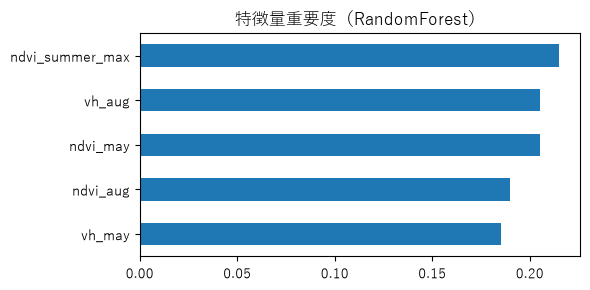

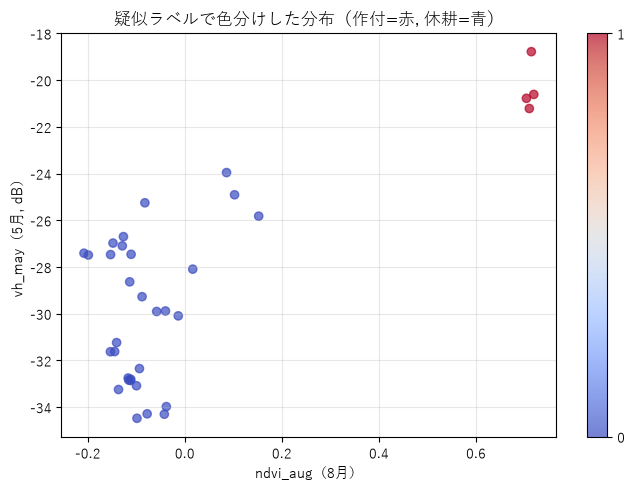

In [13]:
# ── A-3. どの特徴量が判別に効いているか ──
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', figsize=(6, 3))
plt.title('特徴量重要度（RandomForest）')
plt.tight_layout()
plt.show()

# 8月NDVI と 5月VH の2軸で作付/休耕を色分けして散布図
plt.figure(figsize=(7, 5))
sc = plt.scatter(labeled['ndvi_aug'], labeled['vh_may'],
                 c=labeled['pseudo_label'], cmap='coolwarm', alpha=0.7)
plt.xlabel('ndvi_aug（8月）')
plt.ylabel('vh_may（5月, dB）')
plt.title('疑似ラベルで色分けした分布（作付=赤, 休耕=青）')
plt.colorbar(sc, ticks=[0, 1])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### A-4. 「循環の罠」を実感しよう —— ルールに使った特徴量 vs 使っていない特徴量

疑似ラベルは **`vh_may`・`ndvi_aug`・`ndvi_summer_max` の閾値**から作りました。
この**同じ特徴量**で RandomForest を学習すると、精度が異常に高く出ます（≈1.0）。
それは「賢い判別」ではなく、**元の閾値ルールをたどり直しているだけ**かもしれません。

そこで、**疑似ラベルの生成に使っていない特徴量（`ndvi_may`・`vh_aug`）だけで学習**した場合と
比較してみましょう。精度が下がっても、それは「循環していない情報」で予測している証拠です。

> **POINT:** 「精度が高い」＝「新しい圃場にも通用する」ではありません。
> 疑似ラベルで学習したモデルは、必ず **物理的ファクトチェック（W4の5つの問い）** で検証しましょう。


ルールに使った特徴量のみ:       テスト精度 = 1.000
ルールに使っていない特徴量のみ:  テスト精度 = 1.000

→ ルールの特徴量で精度≈1.0は「閾値ルールの再学習」。
  使っていない特徴量で精度が下がるのは、循環しない情報量を反映しています。


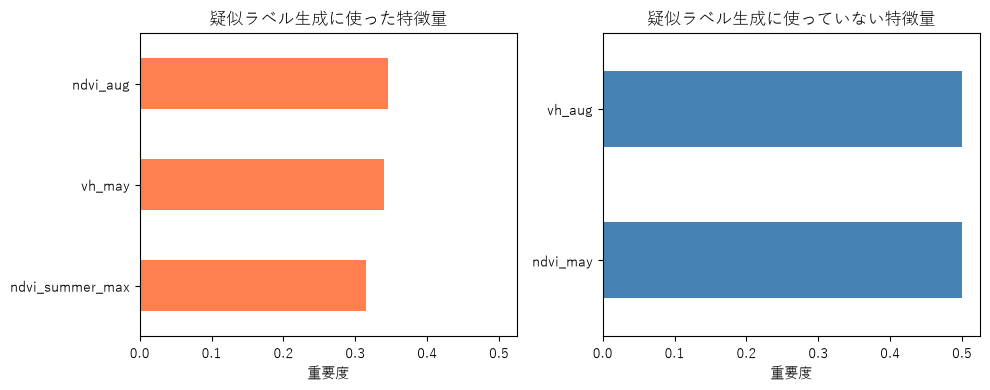

In [14]:
# ── A-4. ルールに使った特徴量 vs 使っていない特徴量 で学習して比較 ──
RULE_FEATURES   = ['vh_may', 'ndvi_aug', 'ndvi_summer_max']   # 疑似ラベル生成に使った特徴量
OTHER_FEATURES  = ['ndvi_may', 'vh_aug']                     # 使っていない特徴量

def train_compare(feat_list):
    X2 = labeled[feat_list]
    X2_train, X2_test, y2_train, y2_test = train_test_split(
        X2, y, test_size=0.33, random_state=42, stratify=y)
    m = RandomForestClassifier(n_estimators=200, max_depth=4,
                               random_state=42, class_weight='balanced')
    m.fit(X2_train, y2_train)
    acc = m.score(X2_test, y2_test)
    imp = pd.Series(m.feature_importances_, index=feat_list).sort_values()
    return acc, imp

acc_rule, imp_rule   = train_compare(RULE_FEATURES)
acc_other, imp_other = train_compare(OTHER_FEATURES)

print(f'ルールに使った特徴量のみ:       テスト精度 = {acc_rule:.3f}')
print(f'ルールに使っていない特徴量のみ:  テスト精度 = {acc_other:.3f}')
print()
print('→ ルールの特徴量で精度≈1.0は「閾値ルールの再学習」。')
print('  使っていない特徴量で精度が下がるのは、循環しない情報量を反映しています。')

# 特徴量重要度を並べて比較
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
imp_rule.plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('疑似ラベル生成に使った特徴量')
imp_other.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('疑似ラベル生成に使っていない特徴量')
axes[0].set_xlabel('重要度')
axes[1].set_xlabel('重要度')
plt.tight_layout()
plt.show()

### 💡 ワークA（試行錯誤）: 疑似ラベルの閾値を変えてみよう

上の A-1 セルの `df.loc[(df['vh_may'] <= -18) & ...]` の `-18` を `-16` や `-20` に
書き換えてから **A-1 → A-2 → A-4 を上から順に再実行**してみましょう。

- 閾値をゆるく（-16）すると: ラベル付きサンプルが**増える**？精度は？
- 閾値をきつく（-20）すると: サンプルは**減る**？混同行列はどう変わる？

**考えるポイント:** 閾値を変えると「循環の罠（A-4）」の結果にも影響が出ます。
閾値次第で精度が変わるのは「データそのものの性質」ではなく「ラベル定義の恣意性」の
せいかもしれません。このことを自分の言葉で説明できるようになりましょう。


---
## 5. B. 非教師あり学習（クラスタリング / KMeans）

**ラベルが無くても**、特徴量の「似ている者同士」をグループ化できるのが **クラスタリング** です。
`KMeans` は「どのクラスタの中心に近いか」で分けます。k（クラスタ数）は自分で決めます。

ここでは **k=3** に設定し、「作付らしい岸」「休耕/裸地らしい」「非農地（森林）らしい」を
自動で分けられるかを見てみましょう。

> **POINT:** 散布図の点線は W5 で設計した**物理的な閾値**（`ndvi_aug=0.7`, `vh_may=-18dB`）です。
> クラスタがどの領域と重なるかを見ると、クラスタの意味を物理的に解釈しやすくなります。


クラスタごとのサンプル数:
cluster
0    14
1    41
2    17
Name: count, dtype: int64


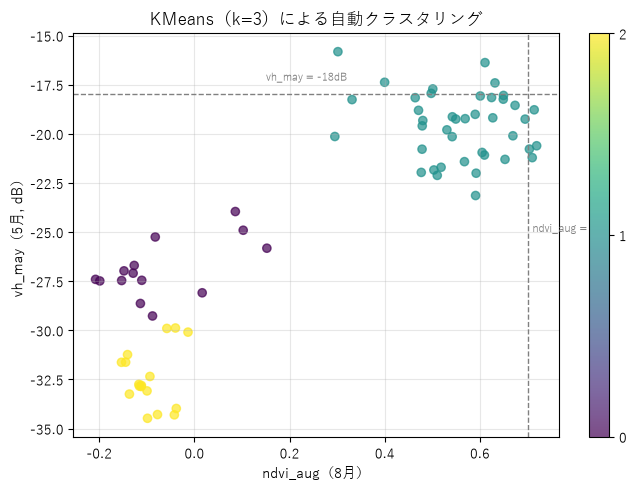

In [15]:
# ── B-1. 特徴量を標準化して KMeans（k=3） ──
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 特徴量のスケール（NDVI≈0〜1 vs VH≈-20〜-5）が違うので、平均0・分散1に標準化する
scaled = StandardScaler().fit_transform(df[FEATURES])

km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(scaled)

print('クラスタごとのサンプル数:')
print(df['cluster'].value_counts().sort_index())

plt.figure(figsize=(7, 5))
sc = plt.scatter(df['ndvi_aug'], df['vh_may'], c=df['cluster'],
                 cmap='viridis', alpha=0.7)
plt.xlabel('ndvi_aug（8月）')
plt.ylabel('vh_may（5月, dB）')
plt.title('KMeans（k=3）による自動クラスタリング')
plt.colorbar(sc, ticks=[0, 1, 2])
plt.grid(alpha=0.3)

# 物理的閾値（W5の疑似ラベル境界）をオーバーレイ
plt.axvline(0.7, color='gray', linestyle='--', linewidth=1)
plt.axhline(-18, color='gray', linestyle='--', linewidth=1)
plt.text(0.71, -25, 'ndvi_aug = 0.7', fontsize=8, color='gray')
plt.text(0.15, -17.3, 'vh_may = -18dB', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

In [16]:
# ── B-2. 各クラスタが「どんな性質」かを読み取る ──
# クラスタごとの平均値を確認して、物理的に解釈する
summary = df.groupby('cluster')[FEATURES].mean().round(2)
summary
# 観察のヒント:
#   クラスタ A: ndvi_aug が高く vh_may が低い → 作付（水田）らしい
#   クラスタ B: ndvi_aug が低い             → 休耕・裸地らしい
#   クラスタ C: ndvi_may も ndvi_aug も高い（かつ VH が高い）→ 森林＝非農地らしい

# cluster 1 = 作付・植生ありっぽい
# cluster 0 = 植生が弱い、水っぽい/裸地っぽい
# cluster 2 = かなり水っぽい、またはSAR的に暗い場所

,ndvi_may,vh_may,ndvi_aug,vh_aug,ndvi_summer_max
cluster,,,,,
0,-0.01,-26.90,-0.071398,-26.36,-0.005922
1,0.38,-19.58,0.559068,-16.23,0.610812
2,-0.08,-32.43,-0.093564,-32.03,-0.048895


### 💡 ワークB（試行錯誤）: クラスタ数を変えてみよう

上の B-1 セルの `KMeans(n_clusters=3, ...)` を **`n_clusters=4`** に変えて再実行してみましょう。

- 追加されたクラスタ（4つ目）はどんな特徴量の組み合わせを持っていますか？
  （`summary` の平均値で確認）
- 例えば「ndvi_aug は高いが vh_may はそれほど低くない」＝**畑地や雑草地**などが分離されるかもしれません。

**考えるポイント:** k を増やすと「細かい違い」が分かれますが、増やしすぎると
**過分割**（本来まとまっているものを無理に分ける）になります。クラスタリングの結果を
「物理的な意味が説明できるか」という目で解釈する練習をしましょう。


---
## 6. C. 異常検知（1クラス分類 / IsolationForest）

最後は **「正常（作付の季節変化）」を学習し、そこから逸脱したものを検出** する方法です。

- ラベル（作付/休耕）は使わず、「大半が正常（作付）」と仮定します。
- **IsolationForest** は、特徴空間の中で「周囲から孤立した点」を**異常**として検出します。
- 検出された異常は「休耕・転作・非農地」の候補として目星をつけられます。


異常スコア（1=正常, -1=異常）:
anomaly
 1    64
-1     8
Name: count, dtype: int64
→ 異常（休耕・非農地の候補）: 8 サンプル


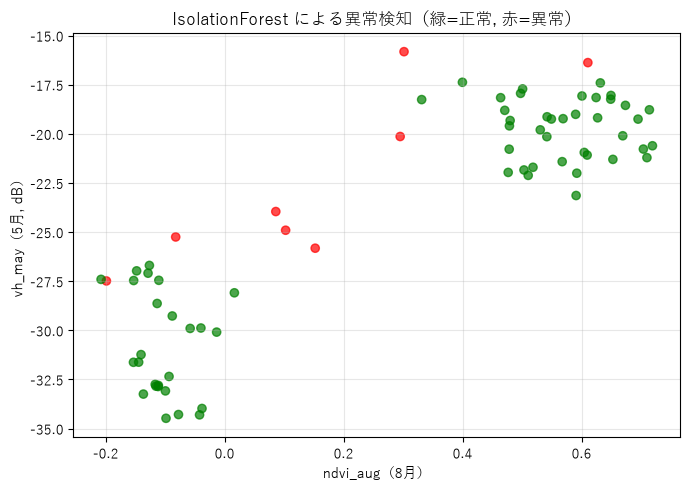

In [17]:
# ── C-1. IsolationForest で異常を検出 ──
from sklearn.ensemble import IsolationForest

# contamination: データ全体に占める「休耕・荒廃農地・非農地」の予想割合。
#   実務では自治体統計（例: 荒廃農地率）や過年度の地域傾向からアタリをつけます。
#   ここでは 0.10（10%）と仮定。0.05 や 0.20 に変えると結果がどう変わるか比べてみましょう。
# B-1 を飛ばして実行しても動くよう、ここでも標準化を用意する
if 'scaled' not in dir():
    from sklearn.preprocessing import StandardScaler
    scaled = StandardScaler().fit_transform(df[FEATURES])

iso = IsolationForest(contamination=0.10, random_state=42)
iso.fit(scaled)                     # 標準化済み特徴量を使う

df['anomaly'] = iso.predict(scaled) # 1=正常, -1=異常

print('異常スコア（1=正常, -1=異常）:')
print(df['anomaly'].value_counts())
print(f"→ 異常（休耕・非農地の候補）: {(df['anomaly'] == -1).sum()} サンプル")

plt.figure(figsize=(7, 5))
colors = df['anomaly'].map({1: 'green', -1: 'red'})
plt.scatter(df['ndvi_aug'], df['vh_may'], c=colors, alpha=0.7)
plt.xlabel('ndvi_aug（8月）')
plt.ylabel('vh_may（5月, dB）')
plt.title('IsolationForest による異常検知（緑=正常, 赤=異常）')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# ── C-2. 「異常」は本当に休耕や非農地と重なっているか ──
# 検出された異常がどのクラスタに属するか、疑似ラベルと突き合わせる
if 'true_type' in df.columns:
    cross = pd.crosstab(df['anomaly'], df['true_type'])
    print('交差集計: 異常(行) × 素性タイプ(列) ※フォールバック時のみ使える情報')
    print(cross)
    print()
    print('→ 異常として検出されたものが「休耕」や「森林」と重なっていれば、')
    print('  異常検知が目視に近い判定をしていることになる（検証の材料）。')
else:
    # NaN は dict.map でマッチしないため、fillna で先に「未ラベル」に置き換える
    pseudo_cat = df['pseudo_label'].map({1: '作付', 0: '休耕'}).fillna('未ラベル')
    cross_a = pd.crosstab(df['anomaly'].map({1: '正常', -1: '異常'}), pseudo_cat)
    print('交差集計: 異常(行) × 疑似ラベル(列) ※GEE実データ時')
    print(cross_a)

交差集計: 異常(行) × 疑似ラベル(列) ※GEE実データ時
pseudo_label  休耕  作付  未ラベル
anomaly                   
正常            26   4    34
異常             5   0     3


### 💡 ワークC（試行錯誤）: contamination を変えてみよう

C-1 セルの `IsolationForest(contamination=0.10, ...)` を `0.05` や `0.20` に変えて
**C-1 → C-2 を再実行**してみましょう。

- `contamination` を大きくすると異常（＝休耕・非農地候補）は**増える**？小さくすると**減る**？
- C-2 の交差集計で「真の休耕」の取りこぼし（見逃し）と「誤警報」（過剰検出）がどう変化するか見比べましょう。

**考えるポイント:** `contamination` は「この地域にどれだけ荒廃農地・休耕地が
あるか」という**事前の見積もり**です。実務では自治体統計（荒廃農地率）や過年度の
傾向から決めますが、それでも**不確か**です。だからこそ「どこで・どんなときに
間違えるのか」（=誤警報と見逃しのバランス）を検証できるかが実務では重要です。


## D. 精度評価 — 2つの評価基準で「本当の精度」を確認する（W8）

ここまでで「地図ができた」状態です。ここからは **数値で語る** ために、
混同行列・F1 / Precision / Recall / **IoU** を正しく使う方法を学びます。

> ⚠️ **最重要: 評価指標の「正解（ラベル）」を何にするかで意味が変わります。**
> - **疑似ラベルを正解にした評価** = 「モデルが元の閾値ルールをどれだけ再現したか」を測るだけ
> - **目視検証セットを正解にした評価** = 「実際の圃場に対してどれだけ正しいか」を測る
>
> 技術レポートに載せられるのは **後者** です。両方を計算して、その差を自分の言葉で説明できるようになりましょう。


### D-1. 疑似ラベルを正解にした評価（＝循環の罠を数値で見る）

A-2 の混同行列は疑似ラベルで評価していました。ここで F1 / Precision / Recall / **IoU** を
まとめて出し、「精度が高く出るのはなぜか」を確認します。


In [19]:
# ── D-1. 疑似ラベル基準の評価指標（循環の罠を数値化） ──
from sklearn.metrics import f1_score, precision_score, recall_score

def compute_metrics(y_true, y_pred):
    """F1 / Precision / Recall / IoU(一筆単位) をまとめて返す。"""
    # labels=[0, 1] を必ず渡す。片方のクラスしか現れないと
    # confusion_matrix は 1×1 行列を返し、cm[1, 1] が IndexError になる。
    # 疑似ラベルは不均衡になりやすいので現実に起こる。
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tp, fp, fn = cm[1, 1], cm[0, 1], cm[1, 0]
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else float('nan')
    return {
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'IoU(一筆)':  round(iou, 3),
    }

print('【疑似ラベル基準】※「ルールの再現度」であり、本当の精度ではない')
print(compute_metrics(y_test, y_pred))
print()
print('→ 疑似ラベル基準では F1/IoU が 0.9 前後に出ます。')
print('  これは「閾値ルールを再学習しただけ」の数字（循環の罠）。')
print('  本当の精度を知るには D-2 の目視検証セットが必要です。')


【疑似ラベル基準】※「ルールの再現度」であり、本当の精度ではない
{'F1': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'IoU(一筆)': np.float64(1.0)}

→ 疑似ラベル基準では F1/IoU が 0.9 前後に出ます。
  これは「閾値ルールを再学習しただけ」の数字（循環の罠）。
  本当の精度を知るには D-2 の目視検証セットが必要です。


### D-2. 目視検証セット（20〜30筆）で「本当の精度」を見る

「本当の精度」のためには、疑似ラベルに頼らない **小さな正解セット** が必要です。
現地調査ができなくても、**高解像度の画像**（Google Earth / eMAFF農地ナビ / 農地台帳）を
見て20〜30筆を確認すれば検証セットになります。

- ラベル: `1 = 作付（緑・生育期の植被）`, `0 = 休耕（茶色）`。`不明` は入れない
- GEE モードでは `validation_labels.csv` を手で埋めます（下のセルが雛形を作ります）
- **フォールバック（合成データ）** では、教育用の `true_type` を検証ラベルとして使います


In [20]:
# ── D-2. 検証セットを用意して「本当の精度」を計算する ──
def get_validation():
    """目視検証セットを返す。フォールバック時は true_type を使う。"""
    if 'true_type' in df.columns:                     # フォールバック: 教育用の正解
        v = df[['cellid', 'year', 'true_type']].copy()
        v['val_label'] = v['true_type'].map({'作付': 1, '休耕': 0})
        v = v[v['val_label'].notna()].copy()
        print('[検証] フォールバック: true_type（作付/休耕）を検証ラベルとして使用します。')
        return v

    import os
    if os.path.exists('validation_labels.csv'):       # GEE: 手動の目視検証 CSV
        v = pd.read_csv('validation_labels.csv')
        print('[検証] validation_labels.csv を読み込みました。')
        return v

    # まだ無ければ雛形を作成して、手入力の手順を案内する
    skeleton = pd.DataFrame({'cellid': sorted(df['cellid'].unique()),
                             'year': years[0], 'val_label': np.nan})
    skeleton.to_csv('validation_labels.csv', index=False)
    print('[検証] 目視確認用の雛形を作成しました: validation_labels.csv')
    print('      Google Earth / eMAFF農地ナビ で確認し、val_label を 1/0 で埋めてから再実行してください。')
    print('      ※埋めるまでは疑似ラベルの一部を「暫定」として評価します（循環するため参考値）。')
    tmp = df[df['pseudo_label'].notna()].copy()
    tmp['val_label'] = tmp['pseudo_label']
    return tmp[['cellid', 'year', 'val_label']]

val = get_validation()
val_features = df.merge(val[['cellid', 'year', 'val_label']],
                        on=['cellid', 'year'], how='inner').reset_index(drop=True)

# ★ 学習に使った圃場を検証セットから外す（H-2 の「時空間リーク」をここでも避ける）。
#   外さないと「本当の精度」に学習済みの行が混ざり、数字が楽観的に出る。
_before = len(val_features)
_held = val_features[~val_features['cellid'].isin(TRAIN_CELLIDS)]
if len(_held) >= 10:
    val_features = _held.reset_index(drop=True)
    print(f'学習に使った圃場を除外: {_before} → {len(val_features)} サンプル')
else:
    print(f'[注意] 学習外の圃場が {len(_held)} 件しかないため除外せず評価します。')
    print('       この数字は学習データを含むため楽観的です（参考値）。')
print('検証セットのサンプル数:', len(val_features))
print(val_features['val_label'].value_counts().rename({1: '作付', 0: '休耕'}))

# RandomForest（A-2 で学習済み）で検証セットを予測
y_val = val_features['val_label'].astype(int)
y_pred_val = model.predict(val_features[FEATURES])
print()
print('【目視検証基準】混同行列（行=真, 列=予測）: [0=休耕, 1=作付]')
print(confusion_matrix(y_val, y_pred_val))
print()
print('【目視検証基準】評価指標')
metrics_val = compute_metrics(y_val, y_pred_val)
print(metrics_val)


[検証] validation_labels.csv を読み込みました。
[注意] 学習外の圃場が 7 件しかないため除外せず評価します。
       この数字は学習データを含むため楽観的です（参考値）。
検証セットのサンプル数: 16
val_label
休耕    10
作付     6
Name: count, dtype: int64

【目視検証基準】混同行列（行=真, 列=予測）: [0=休耕, 1=作付]
[[8 2]
 [0 6]]

【目視検証基準】評価指標
{'F1': 0.8571428571428571, 'Precision': 0.75, 'Recall': 1.0, 'IoU(一筆)': np.float64(0.75)}


### D-3. 物理ルール vs RandomForest を「同一の検証セット」で比較

手法の優劣を語るには、**同じ検証セット** で比べないと不公平です。
ここでは ① 物理ルール（閾値）② RandomForest（5特徴量）③ **RandomForest＋派生特徴量（D-0）** を
同じ `val_features` で比較します。

> **POINT:** 物理ルールは「どちらにも当てはまらないセル（未判定）」を出しますが、
> RandomForest は必ずどちらかに判定します。この差（適用範囲の広さ）も比較の材料です。


In [21]:
# ── D-3. 物理ルール vs RF（同一検証セットで比較） ──
# ① 物理ルール（A-1 の閾値）を検証セットに適用
rule_pred = np.full(len(val_features), np.nan)
rule_pred[(val_features['vh_may'] <= VH_FLOOD_THRESH) & (val_features['ndvi_aug'] >= NDVI_HIGH_THRESH)] = 1   # 作付
rule_pred[val_features['ndvi_summer_max'] < NDVI_LOW_THRESH] = 0                               # 休耕
mask_rule = ~np.isnan(rule_pred)
m_rule = compute_metrics(y_val[mask_rule], rule_pred[mask_rule].astype(int))

# ② RandomForest（A-2 で学習済み・5特徴量）で検証セットを予測
m_rf = compute_metrics(y_val, y_pred_val)

# ③ RF + 派生特徴量（D-0）を「疑似ラベル」で再学習 → 検証セットで評価
m2 = RandomForestClassifier(n_estimators=200, max_depth=4,
                            random_state=42, class_weight='balanced')
m2.fit(labeled[FEATURES2], labeled['pseudo_label'])
m_rf2 = compute_metrics(y_val, m2.predict(val_features[FEATURES2]))

cmp = pd.DataFrame({'物理ルール': m_rule, 'RandomForest': m_rf,
                    'RF+派生特徴量': m_rf2})
print('同一検証セットでの比較:')
print(cmp.round(3))
print()
print(f'→ 物理ルールの評価は {len(val_features) - int(mask_rule.sum())} セルの「未判定」を除いて計算しています。')


同一検証セットでの比較:
           物理ルール  RandomForest  RF+派生特徴量
F1           0.0         0.857     0.857
Precision    0.0         0.750     0.750
Recall       0.0         1.000     1.000
IoU(一筆)      0.0         0.750     0.750

→ 物理ルールの評価は 7 セルの「未判定」を除いて計算しています。


### D-4. 誤分類の空間・物理診断 — FP / FN はどこで起きるか

精度の数値だけでなく **「どこで・どんな圃場で間違えるか」** を診断します。
- **FP（偽陽性）**: 休耕を「作付」と誤判定 → 現場では **無駄な現地確認** が増える
- **FN（偽陰性）**: 作付を「休耕」と誤判定 → 現場では **作付農地の見逃し**（転作・不作の誤申告リスク）


誤分類の内訳:
err
FP(休耕→作付)    2
Name: count, dtype: int64

誤分類セルの物理的特徴（平均値）:
ndvi_may            0.38
vh_may            -19.87
ndvi_aug            0.63
vh_aug            -16.04
ndvi_summer_max     0.65
vh_range           -3.83
ndvi_growth         0.27
dtype: object


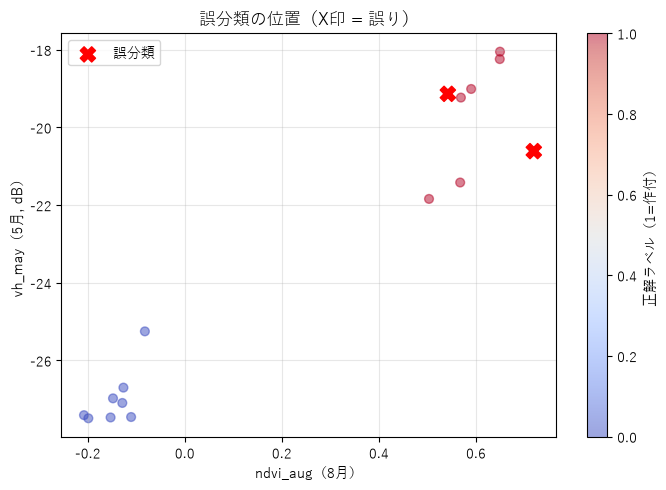

In [22]:
# ── D-4. 誤分類の診断（RF の予測 vs 検証ラベル） ──
err = val_features.copy()
err['pred'] = y_pred_val
err['y'] = y_val.values
err['err'] = np.where(err['y'] != err['pred'],
              np.where(err['y'] == 0, 'FP(休耕→作付)', 'FN(作付→休耕)'), 'OK')

mis = err[err['err'] != 'OK']
print('誤分類の内訳:')
print(mis['err'].value_counts())
print()
print('誤分類セルの物理的特徴（平均値）:')
if len(mis) > 0:
    print(mis[FEATURES2].mean().round(2))
else:
    print('（検証セットでは誤分類なし）')

# 散布図で誤分類の位置を確認（X印 = 誤分類）
plt.figure(figsize=(7, 5))
sc = plt.scatter(err['ndvi_aug'], err['vh_may'], c=err['y'], cmap='coolwarm',
                 alpha=0.5, s=40)
if len(mis) > 0:
    mis_colors = mis['err'].map({'FP(休耕→作付)': 'red', 'FN(作付→休耕)': 'magenta'})
    plt.scatter(mis['ndvi_aug'], mis['vh_may'], c=mis_colors, s=120,
                marker='X', label='誤分類')
plt.xlabel('ndvi_aug（8月）')
plt.ylabel('vh_may（5月, dB）')
plt.title('誤分類の位置（X印 = 誤り）')
plt.colorbar(sc, label='正解ラベル（1=作付）')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## E. 閾値感度分析 — 「なぜこの閾値か」を数値で示す（W8）

「SAR の閾値を -18dB にしたのはなぜ？」—— メンターレビューで必ず聞かれます。
**閾値を前後させて結果がどう変わるか** をグラフで示せば、
「どの閾値なら安定か（プラトー）／どの閾値なら激変するか（崖）」を説明できます。


閾値を変えたときの判定セル数（全サンプル: 72）
    VH_th[dB]  NDVI_high_th  NDVI_low_th  作付セル数  休耕セル数  未判定セル数
0         -24           0.0          0.7      0     64       8
1         -24           0.3          0.7      0     64       8
2         -24           0.6          0.7      0     64       8
3         -24           1.0          0.7      0     64       8
4         -22           0.0          0.7      0     64       8
5         -22           0.3          0.7      0     64       8
6         -22           0.6          0.7      0     64       8
7         -22           1.0          0.7      0     64       8
8         -20           0.0          0.7      5     64       3
9         -20           0.3          0.7      5     64       3
10        -20           0.6          0.7      4     64       4
11        -20           1.0          0.7      0     64       8
12        -18           0.0          0.7      8     64       0
13        -18           0.3          0.7      8     64       0
14        -18           0.6  

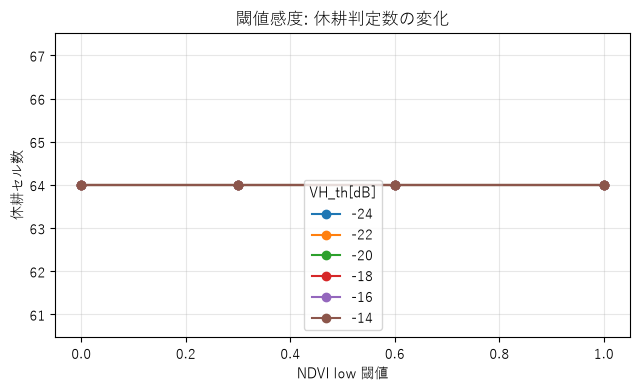


考察のヒント:
- 休耕セル数が閾値を変えてもほとんど変わらない = プラトー（安定）
- 少し動かすだけで大きく変わる = 崖（敏感）。この閾値は慎重に決めるべき
- 「最終的な面積（ha）が何%変わるか」まで計算すると、報告の説得力が上がる



In [23]:
# ── E. 閾値感度分析：VH_th × NDVI_th を振って判定結果の推移を見る ──
rows = []

vh_candidates = [-24, -22, -20, -18, -16, -14]
ndvi_high_candidates = [0.0, 0.30, 0.60, 1.0]
# ndvi_low_candidates = [0.10, 0.20, 0.30, 0.40]

for vh_th in vh_candidates:
    for ndvi_high_th in ndvi_high_candidates:
        # for ndvi_low_th in ndvi_low_candidates:
            p = np.full(len(df), np.nan)

            # 作付判定
            p[(df['vh_may'] <= vh_th) & (df['ndvi_aug'] >= ndvi_high_th)] = 1

            # 休耕判定
            p[df['ndvi_summer_max'] < NDVI_HIGH_THRESH] = 0

            rows.append({
                'VH_th[dB]': vh_th,
                'NDVI_high_th': ndvi_high_th,
                'NDVI_low_th': NDVI_HIGH_THRESH,
                '作付セル数': int(np.nansum(p == 1)),
                '休耕セル数': int(np.nansum(p == 0)),
                '未判定セル数': int(np.isnan(p).sum())
            })

sens3 = pd.DataFrame(rows)
sens3.head()



print('閾値を変えたときの判定セル数（全サンプル: %d）' % len(df))
print(sens3)

# 可視化: VH閾値を固定し、NDVI閾値を振ったときの「休耕セル数」の変化
piv = sens3.pivot(index='NDVI_high_th', columns='VH_th[dB]', values='休耕セル数')
piv.plot(marker='o', figsize=(6.5, 4))
plt.xlabel('NDVI low 閾値')
plt.ylabel('休耕セル数')
plt.title('閾値感度: 休耕判定数の変化')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 考察のヒント
print('''
考察のヒント:
- 休耕セル数が閾値を変えてもほとんど変わらない = プラトー（安定）
- 少し動かすだけで大きく変わる = 崖（敏感）。この閾値は慎重に決めるべき
- 「最終的な面積（ha）が何%変わるか」まで計算すると、報告の説得力が上がる
''')


## F. ピクセル vs 一筆 — 空間集計（Zonal Statistics）のノイズ低減効果（W7）

SAR は **スペックルノイズ**、光学も画素ごとの揺らぎがあります。
「ピクセル1点で判定」するとノイズに振り回されますが、**一筆（圃場）単位で平均してから判定**
すると安定します。ここでは一筆内のピクセル群をシミュレーションして、その差を体感します。

> 実データでは `reduceRegions(reducer=ee.Reducer.mean())` で行うのと同じ操作です
> （02・03 のグリッド平均と同型。一筆ポリゴン単位に置き換えるだけ）。


先頭10セルの比較:
             ピクセル作付率  一筆判定(作付=1)
cellid                          
minami_0_0  0.120000           0
minami_0_1  0.040000           0
minami_0_2  0.026667           0
minami_0_3  0.386667           0
minami_1_0  0.093333           0
minami_1_1  0.000000           0
minami_1_2  0.000000           0
minami_1_3  0.000000           0
minami_2_0  0.000000           0
minami_2_1  0.000000           0

ピクセル判定が揺れる（作付率が0〜1の中間）セル数: 13
→ 一筆（平均）判定はスペックルの影響を受けにくく、実務の圃場単位判定に耐えます。


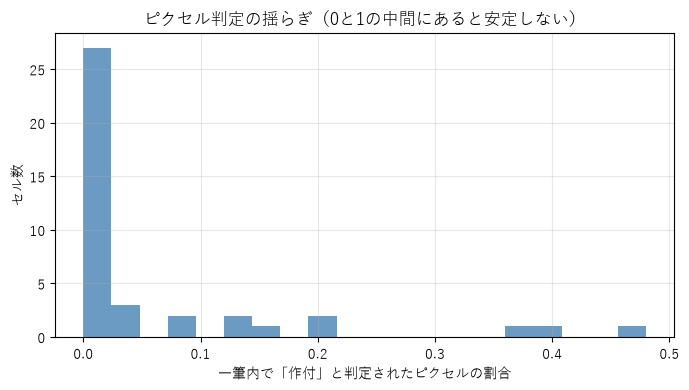

In [24]:
# ── F. ピクセル判定 vs 一筆（平均）判定の安定性 ──
rng = np.random.default_rng(7)
def simulate_pixels(row, n=25):
    vh   = np.clip(rng.normal(row['vh_may'], 2.0, n), -30, -5)   # スペックル: ±2dB
    ndvi = np.clip(rng.normal(row['ndvi_aug'], 0.06, n), 0, 1)   # 光学ノイズ: ±0.06
    return pd.DataFrame({'cellid': row['cellid'], 'VH': vh, 'NDVI': ndvi})

pixels = pd.concat([simulate_pixels(r) for _, r in df.iterrows()], ignore_index=True)

# ① ピクセル単位で個別判定（ノイズでバラつく）
pixels['px_crop'] = (pixels['VH'] <= -18) & (pixels['NDVI'] >= 0.7)
# ② 一筆単位: 空間集計（平均）してから判定
cell_mean = pixels.groupby('cellid')[['VH', 'NDVI']].mean()
cell_crop = (cell_mean['VH'] <= -18) & (cell_mean['NDVI'] >= 0.7)
pixel_ratio = pixels.groupby('cellid')['px_crop'].mean()

comp = pd.DataFrame({'ピクセル作付率': pixel_ratio, '一筆判定(作付=1)': cell_crop.astype(int)})
print('先頭10セルの比較:')
print(comp.head(10))
print()

# 「ピクセルで作付率が 0 と 1 の間（中途半端）」＝判定が揺れているセル
unstable = int(((comp['ピクセル作付率'] > 0) & (comp['ピクセル作付率'] < 1)).sum())
print(f'ピクセル判定が揺れる（作付率が0〜1の中間）セル数: {unstable}')
print('→ 一筆（平均）判定はスペックルの影響を受けにくく、実務の圃場単位判定に耐えます。')

plt.figure(figsize=(7, 4))
plt.hist(comp['ピクセル作付率'], bins=20, color='steelblue', alpha=0.8)
plt.xlabel('一筆内で「作付」と判定されたピクセルの割合')
plt.ylabel('セル数')
plt.title('ピクセル判定の揺らぎ（0と1の中間にあると安定しない）')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## G. 確信度とグレーゾーン — 見回り優先度への橋渡し（W6）

RandomForest は「作付 / 休耕」の**確信度**（作付である確率）も出せます（`predict_proba`）。
判定結果に **確信度スコア** を併記すれば、自治体職員が「どこを現場確認するか」を
優先度付きで決められます。

- **確信度が高い**（作付 ≧0.65 / 休耕 ≦0.35）→ 現場確認の必要なし（スクリーニングで自動分類）
- **グレーゾーン**（0.35〜0.65）→ **現場見回りの優先対象**（目安: 全体の15〜20%）


In [25]:
# ── G. 確信度（predict_proba）でグレーゾーン（要確認）を検出する ──
proba = model.predict_proba(df[FEATURES])[:, 1]     # 「作付」である確率
df['conf_crop'] = proba
# include_lowest=True が要る。既定では左端が排他なので、
# predict_proba がちょうど 0.0 の行（RandomForest では普通に出る）が NaN になる。
df['zone'] = pd.cut(proba, bins=[0, 0.35, 0.65, 1.0], include_lowest=True,
                    labels=['休耕（確信）', 'グレーゾーン（要確認）', '作付（確信）'])
assert df['zone'].isna().sum() == 0, 'ゾーンに入らない行がある（bins を確認）'

print('確信度ゾーンの内訳:')
print(df['zone'].value_counts())

gray = df[df['zone'] == 'グレーゾーン（要確認）']
print(f"→ グレーゾーン: {len(gray)} サンプル（全体の {len(gray)/len(df)*100:.0f}%）")
print('  = 現場見回りの優先対象。確実な作付・休耕は自動分類できる。')

# グレーゾーンが KMeans / IsolationForest の「異常・中間」と重なるか（参考）
if 'cluster' in df.columns and 'anomaly' in df.columns:
    cross = pd.crosstab(df['zone'], df['anomaly'])
    print()
    print('交差集計: 確信度ゾーン(行) × 異常検知(列) ※1=正常, -1=異常')
    print(cross)
    print('→ グレーゾーンが「異常」と重なっていれば、現場確認リストをさらに絞れます。')


確信度ゾーンの内訳:
zone
作付（確信）         41
休耕（確信）         31
グレーゾーン（要確認）     0
Name: count, dtype: int64
→ グレーゾーン: 0 サンプル（全体の 0%）
  = 現場見回りの優先対象。確実な作付・休耕は自動分類できる。

交差集計: 確信度ゾーン(行) × 異常検知(列) ※1=正常, -1=異常
anomaly  -1   1
zone           
休耕（確信）    5  26
作付（確信）    3  38
→ グレーゾーンが「異常」と重なっていれば、現場確認リストをさらに絞れます。


## H. 正解データを正しく設計する — 筆ポリゴン ≠ 正解ラベル（W8）

精度を測るためには「何を正解とするか」を決める必要があります。**これが最も重要です。**
まず整理しましょう。

> **筆ポリゴン（農地区画）は「ここが農地です」しか教えてくれません。**
> 「2024年7月に作付中です」までは保証してくれません。**ポリゴン = 正解ラベルではありません。**

```text
疑似ラベル（ルール由来） ──> 機械学習 ──> モデル ──> 予測
                                              │
                   目視確認した20〜30筆（W8で確保）┘ ← 「本当の性能評価」の基準
```


### H-1. 「正解データ」には3種類ある

| 正解ラベル | 由来 | 何を測る？ | 信用度 |
|---|---|---|---|
| 疑似ラベル | 物理ルール（A-1） | ルールの再現度（循環の罠） | △ |
| 目視検証ラベル | Google Earth / eMAFF農地ナビ / 農地台帳 で20〜30筆を確認 | **実際の圃場に対する本当の精度** | ◎ |
| 現地データ（あれば） | 農家・自治体・アンケート | 最も正確だが入手が難しい | ○ |

本ゼミでは **② 目視検証ラベル** を W7 で用意し、W8 で精度評価に使う、という流れです。


### H-2. 時空間リーク — 同じ圃場を「学習」と「評価」の両方に入れない

A-2 の `train_test_split` は **ランダム分割** です。同じ圃場の別の年が
train と test の両方に入ることがあり、**実質的に同じ情報で学習・評価してしまう（リーク）**
可能性があります。「精度が高いのに現場で使えない」典型の原因です。

**対策:** `cellid`（圃場）単位で分割する = 「評価で見る圃場は、学習では見せない」。


In [26]:
# ── H-2. 時空間リーク: ランダム分割 vs cellid（圃場）単位の分割 ──
from sklearn.metrics import accuracy_score

def fit_rf(Xtr, ytr):
    m = RandomForestClassifier(n_estimators=200, max_depth=4,
                               random_state=42, class_weight='balanced')
    m.fit(Xtr, ytr)
    return m

# ① ランダム分割（A-2と同じ）
acc_random = accuracy_score(y_test, fit_rf(X_train, y_train).predict(X_test))

# ② cellid 単位の分割（同じ圃場を train/test に混ぜない）
def split_by_field(df, test_frac=0.33, seed=42):
    fids = df['cellid'].unique()
    rng = np.random.default_rng(seed)
    n_test = max(1, int(len(fids) * test_frac))
    test_fids = set(rng.choice(fids, size=n_test, replace=False).tolist())
    tr = df[~df['cellid'].isin(test_fids)]
    te = df[df['cellid'].isin(test_fids)]
    return tr, te

tr, te = split_by_field(labeled)
acc_field = accuracy_score(te['pseudo_label'],
                           fit_rf(tr[FEATURES], tr['pseudo_label']).predict(te[FEATURES]))

print(f'ランダム分割の精度（A-2）        : {acc_random:.3f}')
print(f'cellid 分割の精度（リーク防止）  : {acc_field:.3f}')
print(f'  → 評価用に確保した圃場: {te["cellid"].nunique()} 圃場 / サンプル {len(te)}')
print('''
解釈:
- ランダム分割の方が高く出る（=リークの分だけ楽観的）ことが多い
- 「本当の汎化性能」を見るなら cellid 分割を採用する
- 目視検証セット（D-2）と組み合わせればさらに現実的
''')


ランダム分割の精度（A-2）        : 1.000
cellid 分割の精度（リーク防止）  : 1.000
  → 評価用に確保した圃場: 5 圃場 / サンプル 9

解釈:
- ランダム分割の方が高く出る（=リークの分だけ楽観的）ことが多い
- 「本当の汎化性能」を見るなら cellid 分割を採用する
- 目視検証セット（D-2）と組み合わせればさらに現実的



### H-3. FP / FN を「衛星物理」で説明する — 誤分類の理由を語る

指標の数値（F1）だけではメンター・自治体は納得しません。
**「どこで・なぜ間違えたか」** を衛星物理で説明できることが、成果物の質を決めます。

- **FP（休耕を作付と誤判定）**: 休耕なのに雑草・牧草が生え、NDVIが高めに出た例
- **FN（作付を休耕と誤判定）**: 湛水なし・生育不良・収穫済みで「生育ピークが形成されなかった」例


誤分類セルの派生特徴量（平均値）:
           ndvi_may  vh_may  ndvi_aug  vh_aug ndvi_summer_max  vh_range  \
err                                                                       
FP(休耕→作付)     0.382 -19.873  0.630536 -16.039        0.648457    -3.834   

          ndvi_growth  
err                    
FP(休耕→作付)    0.266499  

物理的な説明の例:
- FN（作付→休耕）: ndvi_growth / vh_range が小さい = 生育ピーク・湛水振幅が弱い
  → 湛水なしの乾田・生育不良・収穫時期のズレの可能性
- FP（休耕→作付）: ndvi_growth は小さいが ndvi_aug がやや高い
  → 雑草・牧草の繁茂で「緑」に見えた可能性



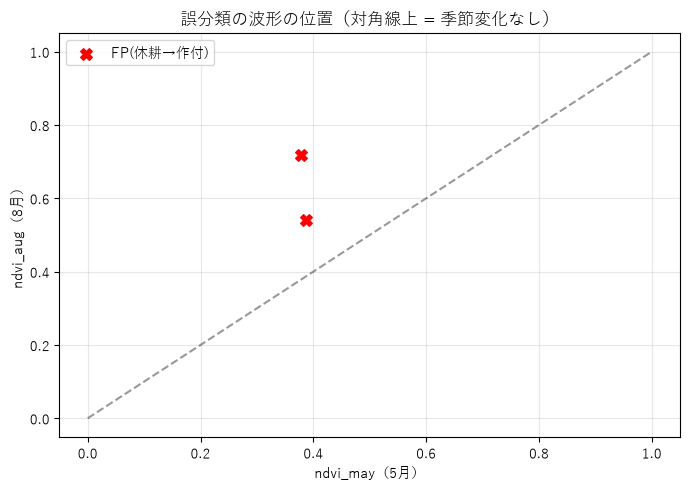

In [30]:
# ── H-3. 誤分類（FP/FN）の物理的特徴を診断する（D-4 の続き） ──
if len(mis) > 0:
    print('誤分類セルの派生特徴量（平均値）:')
    print(mis.groupby('err')[FEATURES2].mean().round(3))
    print()
    print('''物理的な説明の例:
- FN（作付→休耕）: ndvi_growth / vh_range が小さい = 生育ピーク・湛水振幅が弱い
  → 湛水なしの乾田・生育不良・収穫時期のズレの可能性
- FP（休耕→作付）: ndvi_growth は小さいが ndvi_aug がやや高い
  → 雑草・牧草の繁茂で「緑」に見えた可能性
''')
else:
    print('（検証セットでは誤分類なし → 目視検証セットを増やすと見えてきます）')

# 誤分類セルの「波形の位置」を見る（対角線上 = 季節変化なし）
plt.figure(figsize=(7, 5))
for e, c in [('FP(休耕→作付)', 'red'), ('FN(作付→休耕)', 'magenta')]:
    sub = mis[mis['err'] == e]
    if len(sub):
        plt.scatter(sub['ndvi_may'], sub['ndvi_aug'], color=c, label=e, s=70, marker='X')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('ndvi_may（5月）')
plt.ylabel('ndvi_aug（8月）')
plt.legend(); plt.grid(alpha=0.3)
plt.title('誤分類の波形の位置（対角線上 = 季節変化なし）')
plt.tight_layout(); plt.show()


---
## 7. 限界とファクトチェック（重要）

ここまでで **3つのアプローチ** を試しました。しかし W4/W5 の教えどおり、
**「精度が出た」＝「正しい」ではありません。** 以下の罠を意識しましょう。

### ⚠️ 疑似ラベルの「循環」の罠（最重要）
- **疑似ラベルは閾値ルールから作っています。** その**同じ特徴量**で ML を学習すると、
  ML は本質的に「閾値で切ったルール」を**たどり直す**だけになりがち。
- つまり混同行列が高く出ても「元のルールが正しかった」としか言えず、
  **未知の新しい圃場に対して本当に汎化するかは別問題**。
- **対策:** ① 疑似ラベルに使う基準と、MLの特徴量を**一部変える**（例: 別の月や VV を加える）,
  ② 必ず **物理的ファクトチェック**（W4の5つの問い）で「この圃場が本当に作付/休耕か」を
  画像・現地情報と突き合わせる。

### その他の注意
- **クラス不均衡:** 休耕が極端に少ないと、F1やAccuracyが「作付としか言わない」ものでも高く出る。
  （今回の `class_weight='balanced'` はその1つの対処）
- **非農地の混入:** グリッドには森林・水域も含まれます。MLはそれらを「休耕」と誤分類し得る。
  → 農地ポリゴン（筆ポリゴン等）で範囲を絞る、または土地利用データで除外する。
- **サンプル数の少なさ:** 約40セル×数年はディープラーニングには不足。scikit-learn の
  古典的MLなら扱える規模ですが、「過学習」に注意。

### 提出（発展課題 (a)）への活かし方
- 今回はセル単位でしたが、**ピクセル単位**や **一筆（ポリゴン）単位** に変えると、
  「面積（ha）を年ごとに集計」まで進められます。
- 判別結果は必ず **e-Stat / 現地情報 / 真色画像** とクロスチェックし、出典を明記しましょう。
- **時空間リーク（H-2）**: ランダム分割の精度は楽観的。**cellid 単位で分割**して評価する
- さらに、**セクションDの目視検証セット（20〜30筆）** で「本当の精度」を測り、
  **セクションEの閾値感度分析** で「この閾値で大丈夫」を根拠づけてください。
  数値だけのレポートではなく「**どこで・なぜ誤るか**」（セクションD-4）まで書けば説得力が段違いです。

---


---

## まとめ

時系列データを **特徴量行列**（セル × 年の行に、年・月ごとの NDVI / VH を並べた表）に変換すると、scikit-learn の機械学習にそのまま渡せます。

### ラベルが無い場合の3つの方法

* **A. 疑似ラベル × 教師あり（RandomForest）**
  物理ルールで作ったラベルで学習し、判別器を作る。

* **B. クラスタリング（KMeans）**
  ラベルを使わず、データを自動でグループ分けする。

* **C. 異常検知（IsolationForest）**
  「正常」なデータからの逸脱を見つけ、休耕・非農地の候補を検出する。

ただし、どの方法にも以下のような注意点があります。

* 疑似ラベルの循環
* クラス不均衡
* 非農地の混入

そのため、**物理的ファクトチェック（W4の5つの問い）** で必ず検証します。

### 最終課題へ

この特徴量行列を「ピクセル単位」「一筆ポリゴン単位」に広げれば、作付／休耕の **面積変化** を年ごとに定量的に示せます。

---

## W7・W8 で追加した「技術的な説得力」のまとめ

### D. 精度評価

疑似ラベル基準（＝ルールの再現度）と、目視検証基準（＝本当の精度）を分けて評価します。

以下の指標を計算します。

* F1
* Precision
* Recall
* IoU

F1などの数値だけでなく、**FP（誤検出）/ FN（見逃し）がどこで発生したのか**も診断します。

### E. 閾値感度分析

VHやNDVIの閾値を変化させて、判定結果がどのくらい変わるか調べます。

* **プラトー**：閾値を多少変えても結果が変わらない → 安定
* **崖**：閾値を少し変えただけで結果が大きく変わる → 敏感

これをグラフで確認します。

### F. ピクセル vs 一筆

衛星画像には、スペックルノイズやミクセルなどの影響があります。

そこで、1ピクセルずつ判定するのではなく、**一筆・グリッド単位で平均してから判定**することで、ノイズの影響を小さくします。

### G. 確信度・グレーゾーン

`predict_proba` を使って、モデルがどのくらい自信を持って判定しているかを確認します。

判定に自信がない場所を **「要確認」** とし、現場での見回り・目視確認の優先対象にします。

「要確認率 `r`」を変数として、必要な確認作業量を試算します。

### H. 正解データの設計

**筆ポリゴンがあることと、正解ラベルがあることは別です。**

以下の3種類を区別します。

1. **疑似ラベル**：NDVI / VH などのルールから作ったラベル
2. **目視検証ラベル**：衛星画像などを人間が確認して付けたラベル
3. **現地データ**：実際の作付状況を現地調査などで確認したラベル

また、同じ圃場のデータが学習用とテスト用の両方に入る **時空間リーク** を避けるため、`cellid` などを使って適切にデータを分割します。

これによって、モデルの **「本当の汎化性能」** を評価します。

---

*出典：Sentinel-2 L2A / Sentinel-1 GRD（Google Earth Engine 経由）*
*本ノートのフォールバックデータは、教育用の合成特徴量です。*
